In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
dataset = load_dataset("MLLab-TS/heart_disease_uci")

df = pd.DataFrame(dataset['train'])
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.info()
df.columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df = df.replace("?", np.nan)
df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.rename(columns={df.columns[-1]: 'label'}, inplace=True)

X = df.drop('label', axis=1)
y = df['label']

print("Columns:", df.columns)
print("Unique values in target:", sorted(y.unique()))
print("Number of classes:", len(y.unique()))

Columns: Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num',
       'sex_Male', 'dataset_Hungary', 'dataset_VA Long Beach',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_normal', 'label'],
      dtype='object')
Unique values in target: [np.False_, np.True_]
Number of classes: 2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm = SVC(kernel='rbf', decision_function_shape='ovr')

svm.fit(X_train_scaled, y_train)

SVC()

In [ ]:
y_pred = svm.predict(X_test_scaled)

print("=== Basic SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== Basic SVM ===
Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.91      0.94        35
        True       0.89      0.96      0.92        25

    accuracy                           0.93        60
   macro avg       0.93      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



In [ ]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf'],
    'decision_function_shape': ['ovr']
}

grid = GridSearchCV(SVC(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

In [ ]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'decision_function_shape': ['ovr'],
                         'gamma': ['scale', 0.01, 0.001], 'kernel': ['rbf']},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'decision_function_shape': 'ovr', 'gamma': 0.001, 'kernel': 'rbf'}


In [ ]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

print("=== Tuned SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

=== Tuned SVM ===
Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.89      0.94        35
        True       0.86      1.00      0.93        25

    accuracy                           0.93        60
   macro avg       0.93      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



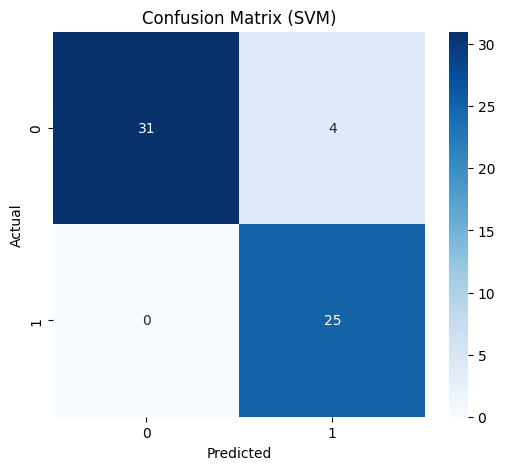

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Basic SVM", "Tuned SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_best)
    ]
})

results

,Model,Accuracy
0,Basic SVM,0.933333
1,Tuned SVM,0.933333


## 📝 Support Vector Machine (SVM) with Hyperparameter Tuning – Heart Disease Dataset

This experiment implements Support Vector Machine (SVM) for classification using the Heart Disease dataset (`MLLab-TS/heart_disease_uci`) and applies hyperparameter tuning to improve model performance.

---

### 🔹 1. Objective
To implement SVM for classification and optimize its performance using hyperparameter tuning (GridSearchCV).

---

### 🔹 2. Dataset Description
The Heart Disease dataset is a real-world medical dataset used to predict the presence of heart disease.

Key features include:
- age → age of the patient  
- sex → gender  
- cp → chest pain type  
- trestbps → resting blood pressure  
- chol → cholesterol level  
- thalach → maximum heart rate  
- oldpeak → ST depression  
- and other clinical attributes  

Target variable:
- Indicates presence (1) or absence (0) of heart disease  

---

### 🔹 3. Data Loading and Inspection
The dataset is loaded from Hugging Face and converted into a Pandas DataFrame.

We use:
- `df.info()` → to check structure and data types  
- `df.describe()` → to view statistical summary  
- `df.columns` → to identify features  

---

### 🔹 4. Data Preprocessing

#### ✔ Handling Missing Values
- Missing values (if present) are replaced with `NaN` and removed  

#### ✔ Encoding Categorical Variables
- Categorical features are converted into numerical form using one-hot encoding (`pd.get_dummies`)  

---

### 🔹 5. Feature and Target Selection
- The last column is dynamically renamed to `label`  
- Features (`X`) = all columns except `label`  
- Target (`y`) = `label`  

This ensures robustness across datasets with different target names.

---

### 🔹 6. Nature of Classification
- The dataset is inherently **binary classification**:
  - 0 → No heart disease  
  - 1 → Heart disease present  

No additional transformation was applied to the target variable.

---

### 🔹 7. Train-Test Split
- Dataset is split into:
  - 80% training data  
  - 20% testing data  

This allows evaluation on unseen data.

---

### 🔹 8. Feature Scaling
- Standardization is applied using `StandardScaler`  
- Important because SVM is sensitive to feature magnitudes  

---

### 🔹 9. Support Vector Machine (SVM)
- SVM finds the optimal hyperplane that separates classes  
- Uses kernel functions to handle non-linear data  

In this experiment:
- RBF (Radial Basis Function) kernel is used  
- One-vs-Rest (OvR) strategy is applied for classification  

---

### 🔹 10. Basic SVM Model
- A default SVM model is trained  
- Provides baseline accuracy before tuning  

---

### 🔹 11. Hyperparameter Tuning (GridSearchCV)

GridSearchCV is used to find the best combination of parameters:

- **C (Regularization parameter)**:
  - Controls trade-off between margin and misclassification  
  - Higher C → less tolerance for errors  

- **gamma**:
  - Controls influence of individual data points  
  - Higher gamma → more complex decision boundary  

- **kernel**:
  - Defines transformation of input data (RBF used here)  

---

### 🔹 12. Model Evaluation

#### ✔ Accuracy Score
- Measures overall correctness of predictions  

#### ✔ Classification Report
- Precision → correctness of predictions  
- Recall → ability to detect all positive cases  
- F1-score → balance between precision and recall  

#### ✔ Confusion Matrix
- Displays actual vs predicted values  
- Since the dataset is binary, the matrix is **2×2**  

---

### 🔹 13. Model Comparison
- Performance of basic SVM and tuned SVM is compared  
- Tuned model generally achieves higher accuracy  

---

### 🔹 14. Conclusion
- SVM is effective for medical classification tasks  
- Feature scaling significantly improves performance  
- Hyperparameter tuning enhances model accuracy  
- Binary classification simplifies interpretation in healthcare  

---

### 🧠 Key Learning
- SVM maximizes margin between classes  
- Kernel functions allow handling non-linear data  
- Hyperparameters (C and gamma) strongly influence performance  
- GridSearchCV automates optimal parameter selection  